In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [2]:
DATA_ROOT = Path.home() / "Desktop" / "coingecko"

SOURCE_DIRS = [
    DATA_ROOT / "coin_gecko",
    DATA_ROOT / "coin_gecko_20250910_112201",
    DATA_ROOT / "20260531_130117_stablecoins",
]

FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(exist_ok=True)

In [3]:
x_coin = "usd-coin"
y_coin = "dai"

x_label = "USDC"
y_label = "DAI"

peg_value = 1.0
end_date = "2026-05-31"

In [4]:
def read_price_series(coin_id):
    data_list = []

    for folder in SOURCE_DIRS:
        file = folder / f"{coin_id}.csv"

        if file.exists():
            temp = pd.read_csv(file)
            temp["date"] = pd.to_datetime(temp["date"])
            temp = temp[["date", "prices"]]
            data_list.append(temp)

    if not data_list:
        raise FileNotFoundError(f"No price data found for {coin_id}")

    data = pd.concat(data_list, ignore_index=True)

    data = (
        data.sort_values("date")
            .drop_duplicates("date", keep="last")
            .query("date <= @end_date")
            .reset_index(drop=True)
    )

    return data

In [5]:
x_data = read_price_series(x_coin)
y_data = read_price_series(y_coin)

sample = x_data.merge(
    y_data,
    on="date",
    suffixes=("_x", "_y")
)

In [6]:
sample["x_dev"] = sample["prices_x"] - peg_value
sample["y_dev"] = sample["prices_y"] - peg_value

sample = sample[["date", "x_dev", "y_dev"]].dropna()

print(sample["date"].min(), sample["date"].max())
print(sample.head())

2019-11-19 00:00:00 2026-05-31 00:00:00
        date     x_dev     y_dev
0 2019-11-19  0.002247  0.000651
1 2019-11-20  0.002238 -0.004589
2 2019-11-21  0.002644 -0.008409
3 2019-11-22  0.002755 -0.008898
4 2019-11-23  0.000184 -0.007150


In [7]:
reg_sample = sample.copy()

reg_sample = reg_sample.replace([np.inf, -np.inf], np.nan)
reg_sample = reg_sample.dropna()

In [8]:
x_bounds = reg_sample["x_dev"].quantile([0.005, 0.995])
y_bounds = reg_sample["y_dev"].quantile([0.005, 0.995])

reg_sample = reg_sample[
    reg_sample["x_dev"].between(x_bounds.iloc[0], x_bounds.iloc[1])
    & reg_sample["y_dev"].between(y_bounds.iloc[0], y_bounds.iloc[1])
].copy()

print("Observations:", len(reg_sample))

Observations: 2339


In [9]:
X = sm.add_constant(reg_sample["x_dev"])
y = reg_sample["y_dev"]

ols = sm.OLS(y, X).fit()

qr_05 = sm.QuantReg(y, X).fit(
    q=0.05,
    max_iter=10000,
    p_tol=1e-6
)

qr_50 = sm.QuantReg(y, X).fit(
    q=0.50,
    max_iter=10000,
    p_tol=1e-6
)

In [10]:
results = pd.DataFrame({
    "OLS": ols.params,
    "Q05": qr_05.params,
    "Q50": qr_50.params
})

print(results)

            OLS       Q05       Q50
const  0.001173 -0.001744  0.000033
x_dev  0.219083  0.425725  0.647660


In [11]:
x_grid = np.linspace(
    reg_sample["x_dev"].quantile(0.01),
    reg_sample["x_dev"].quantile(0.99),
    200
)

x_grid_model = sm.add_constant(
    pd.Series(x_grid, name="x_dev")
)

fit_ols = ols.predict(x_grid_model)
fit_q05 = qr_05.predict(x_grid_model)
fit_q50 = qr_50.predict(x_grid_model)

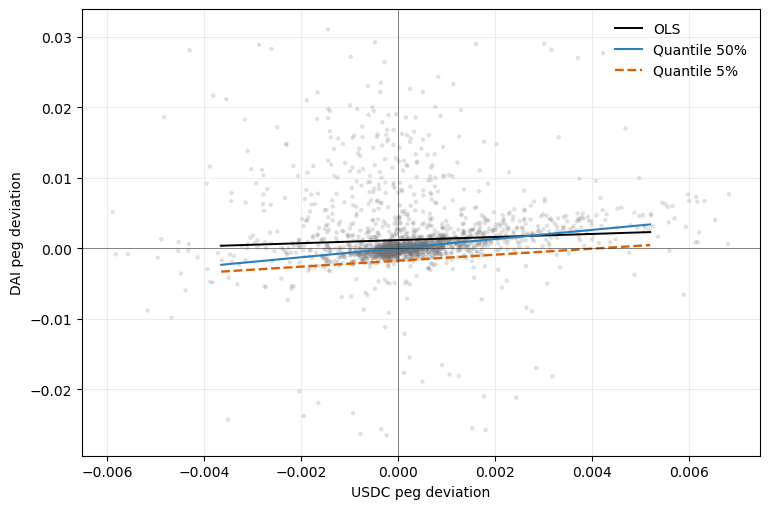

In [12]:
fig, ax = plt.subplots(figsize=(7.8, 5.2))

ax.scatter(
    reg_sample["x_dev"],
    reg_sample["y_dev"],
    s=10,
    alpha=0.22,
    color="0.45",
    edgecolor="none"
)

ax.plot(
    x_grid,
    fit_ols,
    color="black",
    linewidth=1.4,
    label="OLS"
)

ax.plot(
    x_grid,
    fit_q50,
    color="#2c7fb8",
    linewidth=1.5,
    label="Quantile 50%"
)

ax.plot(
    x_grid,
    fit_q05,
    color="#d95f02",
    linewidth=1.7,
    linestyle="--",
    label="Quantile 5%"
)

ax.axhline(0, color="black", linewidth=0.7, alpha=0.45)
ax.axvline(0, color="black", linewidth=0.7, alpha=0.45)

ax.set_xlabel(f"{x_label} peg deviation")
ax.set_ylabel(f"{y_label} peg deviation")

ax.legend(frameon=False)
ax.grid(alpha=0.22)

plt.tight_layout()

In [13]:
figure_name = "mean_quantile_regression_stablecoin_deviation.png"
figure_path = FIGURE_DIR / figure_name

fig.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Saved figure:", figure_path)

Saved figure: figures/mean_quantile_regression_stablecoin_deviation.png
